# Bayesian Optimization for Bioreactor material and CHOL input selection

Three surrogate models are compared:
- **ModelListGP**: two independent GPs (one per output), standard BoTorch baseline
- **MultiTaskGP (MTGP)**: `KroneckerMultiTaskGP`, captures output correlation
- **RandomForest**: sklearn RF wrapped as a BoTorch-compatible model using tree-ensemble variance as proxy uncertainty

Each model runs **batch BO** ($q=3$) via `qNEHVI` (for GPs) and a `qNEI`-analogue for the RF wrapper.

In [14]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import shuffle
from sklearn.utils import check_random_state

# BoTorch / GPyTorch

## 1. Load Dataset and Inspect

In [5]:
full_inputs_df = pd.read_excel("Materials Dataset.xlsx", sheet_name="Inputs")
full_outputs_df = pd.read_excel("Materials Dataset.xlsx", sheet_name="Outputs")

full_inputs_df

,material,thickness,density,porosity,moisture_abs,CHOL_input
0,Poplar,3.094,279,60.1,6.5,0.784
1,Poplar,3.094,279,60.1,6.5,1.618
2,Poplar,3.094,279,60.1,6.5,3.290
3,Poplar,3.094,279,60.1,6.5,6.144
4,Kapok,4.050,312,65.0,6.5,0.802
5,Kapok,4.050,312,65.0,6.5,1.578
6,Kapok,4.050,312,65.0,6.5,3.165
7,Kapok,4.050,312,65.0,6.5,5.625
8,Milkweed,4.070,317,65.0,6.5,0.790
9,Milkweed,4.070,317,65.0,6.5,1.638


For now, `moisture_abs` is redundant so we can exclude it from the training.

In [6]:
full_outputs_df

,surface_productivity,surface_productivity_SD,biomass_productivity,biomass_productivity_SD,product_conc,product_conc_SD,yield,yield_SD,biomass,biomass_SD
0,12.478,0.348,0.432,0.041,0.809,0.023,103.215,2.880,26.549,2.290
1,22.890,0.922,0.795,0.090,1.484,0.060,91.691,3.694,26.549,2.290
2,42.774,3.040,1.486,0.343,2.772,0.197,84.267,5.989,26.549,2.290
3,20.596,1.982,0.708,0.023,1.335,0.128,21.728,2.091,26.549,2.290
4,12.197,0.792,0.517,0.017,0.826,0.027,102.994,3.408,22.526,0.526
5,20.955,0.846,0.889,0.037,1.421,0.036,90.013,2.307,22.526,0.526
6,34.541,4.217,1.459,0.103,2.334,0.200,73.762,6.318,22.526,0.526
7,15.018,0.876,0.637,0.027,1.018,0.036,18.091,0.646,22.526,0.526
8,12.328,0.854,0.523,0.029,0.835,0.043,105.740,5.455,22.207,1.761
9,21.866,1.139,0.928,0.043,1.482,0.053,90.484,3.246,22.207,1.761


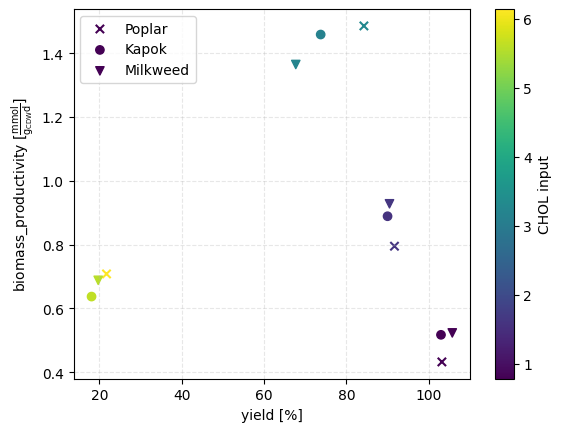

In [15]:
#-----------------------------------------------
# Visualize outputs
#-----------------------------------------------

# Select inputs
inputs_df = full_inputs_df.drop(['moisture_abs'], axis=1)

# Select outputs
output_1 = 'yield'
output_2 = 'biomass_productivity'
outputs_df = full_outputs_df[[output_1, output_1 + '_SD', output_2, output_2 + '_SD']]

# Set color mapping for different materials
material_shapes = {'Poplar': 'x', "Kapok": 'o', 'Milkweed': 'v'}

# Set up CHOL values for the colorbar
chol = full_inputs_df['CHOL_input']
norm = mpl.colors.Normalize(vmin = chol.min(), vmax = chol.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots()

# Plot each material separately
for material, mark in material_shapes.items():
    mask = full_inputs_df['material'] == material

    ax.scatter(
        outputs_df.loc[mask, output_1], 
        outputs_df.loc[mask, output_2],
        c=chol.loc[mask],
        cmap=cmap,
        norm=norm, 
        label=material, 
        marker=mark
    )

# Add colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('CHOL input')

ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlabel(output_1 + ' [%]')
ax.set_ylabel(output_2 + r' [$\frac{\mathrm{mmol}}{\mathrm{g_{CDW} d}}$]')
ax.legend()

plt.show()

In [18]:
X_raw = inputs_df.drop(['material'], axis=1)
Y_raw = outputs_df

In [22]:
X_raw

,thickness,density,porosity,CHOL_input
0,3.094,279,60.1,0.784
1,3.094,279,60.1,1.618
2,3.094,279,60.1,3.290
3,3.094,279,60.1,6.144
4,4.050,312,65.0,0.802
5,4.050,312,65.0,1.578
6,4.050,312,65.0,3.165
7,4.050,312,65.0,5.625
8,4.070,317,65.0,0.790
9,4.070,317,65.0,1.638


In [23]:
Y_raw

,yield,yield_SD,biomass_productivity,biomass_productivity_SD
0,103.215,2.880,0.432,0.041
1,91.691,3.694,0.795,0.090
2,84.267,5.989,1.486,0.343
3,21.728,2.091,0.708,0.023
4,102.994,3.408,0.517,0.017
5,90.013,2.307,0.889,0.037
6,73.762,6.318,1.459,0.103
7,18.091,0.646,0.637,0.027
8,105.740,5.455,0.523,0.029
9,90.484,3.246,0.928,0.043
